In [5]:

import numpy as np 
import pandas as pd
import os
import cv2

# The path can also be read from a config file, etc.
OPENSLIDE_PATH = "C:/Users/Manuel/Downloads/openslide-win64-20231011/bin"
DATA_PATH = "E:/ML/UBC"

if hasattr(os, 'add_dll_directory'):
    # Windows
    with os.add_dll_directory(OPENSLIDE_PATH):
        import py_wsi
        import py_wsi.imagepy_toolkit as tk

In [6]:
# df = pd.read_csv("/kaggle/input/UBC-OCEAN/train.csv")
# df[df["image_id"]==41586]

In [7]:
dirNames = []
for root, dirs, files in os.walk(os.path.join(DATA_PATH,"PKGOvarianBevacizumabResponse")):
    dirNames = [*dirNames, *dirs]

dirNames = dirNames[18:]
dirNames

['in7', 'in8', 'in9']

In [8]:
file_dir = os.path.join(DATA_PATH, "PKGOvarianBevacizumabResponse/e1/")
db_location = "E:/ML/UBC/PKGOvarianBevacizumabResponse/"
xml_dir = file_dir
patch_size = 384
level = 15
db_name = "patchesDB"
overlap = 0

# All possible labels mapped to integer ids in order of increasing severity.
label_map = {'Normal': 0,
             'Benign': 1,
             'Carcinoma in situ': 2,
             'In situ carcinoma': 2,
             'Carcinoma invasive': 3,
             'Invasive carcinoma': 3,
            }

turtle = py_wsi.Turtle(file_dir, db_location, db_name, xml_dir=xml_dir)

Storage type:               lmdb
Images directory:           E:/ML/UBC\PKGOvarianBevacizumabResponse/e1/
Data store directory:       E:/ML/UBC/PKGOvarianBevacizumabResponse/
Images found:               7


In [9]:
# level_count, level_tiles, level_dims = turtle.retrieve_tile_dimensions('312402Q.svs', patch_size=384)
# print("Level count:         " + str(level_count))
# print("Level tiles:         " + str(level_tiles))
# print("Level dimensions:    " + str(level_dims))
# print("XML files found:     " + str(turtle.get_xml_files()))

In [10]:
# print("Total WSI images:    " + str(turtle.num_files))
# print("LMDB name:           " + str(turtle.db_name))
# print("File names:          " + str(turtle.files))


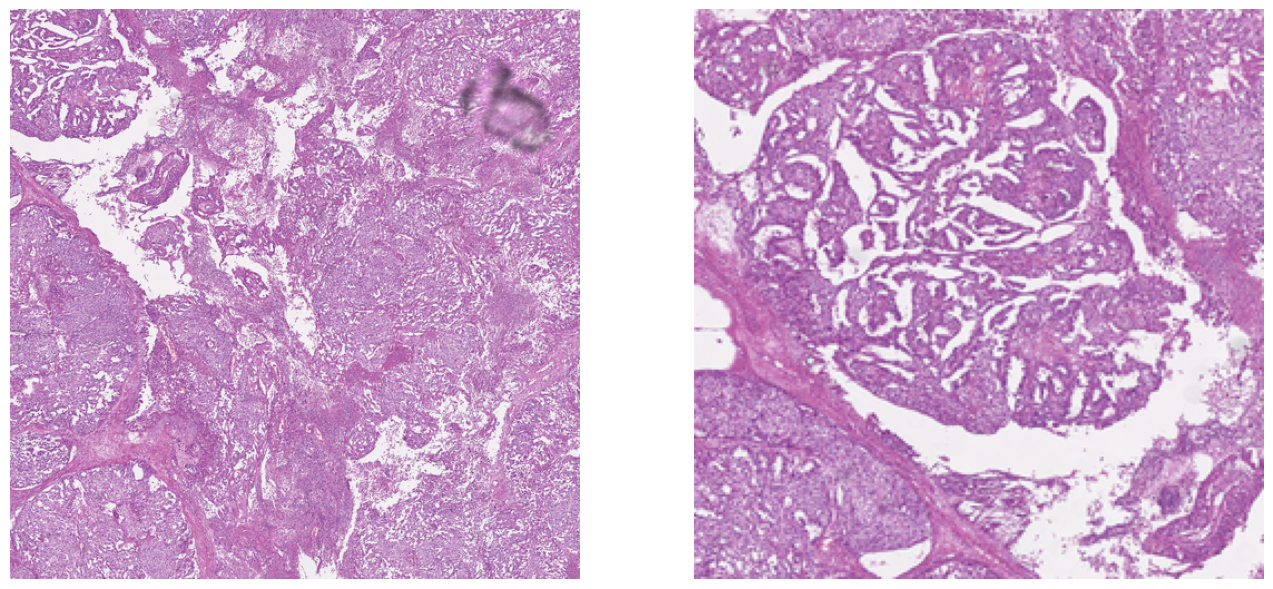

In [11]:
patch_1 = turtle.retrieve_sample_patch("1427159G-Y.svs", 512, 12, overlap=12)
patch_2 = turtle.retrieve_sample_patch("1427159G-Y.svs", 256, 12, overlap=12)
tk.show_images([patch_1, patch_2], 3, 1)

In [12]:
# print("Patch size:", patch_size)
# turtle.sample_and_store_patches(patch_size, level, overlap, load_xml=False, limit_bounds=False)

In [13]:
# patches, coords, classes, labels = turtle.get_patches_from_file("312402Q.svs")
# tk.show_labeled_patches(patches[:10], coords[:10])

In [14]:
# np.max(patches[0])

## Extract patches

In [15]:
from tqdm import tqdm

samplesAmount = 100

allData = {}
db_location = os.path.join(DATA_PATH, "PKG-OBR_Patches/")
patch_size = 384
level = 15
overlap = 0

for num, dirname in tqdm(enumerate(dirNames)):
    fileDir = os.path.join(DATA_PATH, f"PKGOvarianBevacizumabResponse/{dirname}/")
    db_name = "patchDB"

    turtle = py_wsi.Turtle(fileDir, db_location, db_name)
    turtle.sample_and_store_patches(patch_size, level, overlap, load_xml=False, limit_bounds=False)

    fileList = [f for f in os.listdir(fileDir) if os.path.isfile(os.path.join(fileDir, f))]
    print(fileList)
    for f in fileList:
        patches, coords, classes, labels = turtle.get_patches_from_file(f)
        patches = np.array(patches)
        subSamples = patches[np.random.randint(patches.shape[0], size=samplesAmount), :]
        fileSubDir = os.path.join(db_location, f.split(".")[0])
        if not os.path.exists(fileSubDir):
            os.mkdir(fileSubDir)
        for number in range(samplesAmount):
            cv2.imwrite(os.path.join(fileSubDir, str(number)+".png"), subSamples[number, :])

0it [00:00, ?it/s]

Storage type:               lmdb
Images directory:           E:/ML/UBC\PKGOvarianBevacizumabResponse/in7/
Data store directory:       E:/ML/UBC\PKG-OBR_Patches/
Images found:               13
Pre-calculated map sizes:
 - patch db:     387815178240 bytes
 - meta db:      8015360 bytes
Creating new LMDB environment...
1625960B.svs 1707649E.svs 1822186A.svs 210190D.svs 210190H.svs 210190V.svs 220725B.svs 220725C.svs 220725G.svs 223338G.svs 407984-T-N.svs 902765.svs P001716341A.svs 
====== LMDB patchDB Stats ======
{'psize': 4096, 'depth': 3, 'branch_pages': 5, 'leaf_pages': 354, 'overflow_pages': 3274578, 'entries': 30042}
====== LMDB patchDB_meta Stats ======
{'psize': 4096, 'depth': 1, 'branch_pages': 0, 'leaf_pages': 1, 'overflow_pages': 0, 'entries': 13}
Time usage: 0:25:46
['1625960B.svs', '1707649E.svs', '1822186A.svs', '210190D.svs', '210190H.svs', '210190V.svs', '220725B.svs', '220725C.svs', '220725G.svs', '223338G.svs', '407984-T-N.svs', '902765.svs', 'P001716341A.svs']
[py-wsi]:

1it [26:26, 1586.86s/it]

Storage type:               lmdb
Images directory:           E:/ML/UBC\PKGOvarianBevacizumabResponse/in8/
Data store directory:       E:/ML/UBC\PKG-OBR_Patches/
Images found:               5
Pre-calculated map sizes:
 - patch db:     248370167808 bytes
 - meta db:      5133312 bytes
Creating new LMDB environment...
1525978X.svs 1625960A.svs 1625960D.svs 1902979C-N.svs P00181938C.svs 
====== LMDB patchDB Stats ======
{'psize': 4096, 'depth': 3, 'branch_pages': 6, 'leaf_pages': 568, 'overflow_pages': 5392339, 'entries': 49471}
====== LMDB patchDB_meta Stats ======
{'psize': 4096, 'depth': 1, 'branch_pages': 0, 'leaf_pages': 1, 'overflow_pages': 0, 'entries': 18}
Time usage: 0:17:09
['1525978X.svs', '1625960A.svs', '1625960D.svs', '1902979C-N.svs', 'P00181938C.svs']
[py-wsi]: no labels found for these patches.
[py-wsi]: no labels found for these patches.
[py-wsi]: no labels found for these patches.
[py-wsi]: no labels found for these patches.
[py-wsi]: no labels found for these patches.


2it [44:04, 1275.50s/it]

Storage type:               lmdb
Images directory:           E:/ML/UBC\PKGOvarianBevacizumabResponse/in9/
Data store directory:       E:/ML/UBC\PKG-OBR_Patches/
Images found:               17
Pre-calculated map sizes:
 - patch db:     825088868352 bytes
 - meta db:      17052928 bytes
Creating new LMDB environment...
312402.svs 312402A.svs 312402B.svs 312402C.svs 312402D.svs 312402E.svs 312402F.svs 312402G.svs 312402H.svs 312402N.svs 312402O.svs 312402P.svs 312402Q.svs 312402R.svs 312402S.svs 312402T.svs 312402V.svs 
====== LMDB patchDB Stats ======
{'psize': 4096, 'depth': 3, 'branch_pages': 13, 'leaf_pages': 1273, 'overflow_pages': 12434066, 'entries': 114074}
====== LMDB patchDB_meta Stats ======
{'psize': 4096, 'depth': 1, 'branch_pages': 0, 'leaf_pages': 1, 'overflow_pages': 0, 'entries': 35}
Time usage: 1:00:59
['312402.svs', '312402A.svs', '312402B.svs', '312402C.svs', '312402D.svs', '312402E.svs', '312402F.svs', '312402G.svs', '312402H.svs', '312402N.svs', '312402O.svs', '31240

3it [1:45:53, 2117.71s/it]


In [16]:
patches = np.array(patches)

In [17]:
patches[np.random.randint(patches.shape[0], size=2), :].shape

(2, 384, 384, 3)